In [9]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

from src.data_loader import load_brent_prices, load_key_events

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)

df = load_brent_prices()
events_df = load_key_events()

print(df.shape)
df.head()

2026-07-12 15:45:24,619 - INFO - Trimmed 31 rows beyond analysis end date 2022-09-30
2026-07-12 15:45:24,621 - INFO - Loaded 8980 rows, 1987-05-20 to 2022-09-30
2026-07-12 15:45:24,634 - INFO - Loaded 15 key events


(8980, 3)


,Price,Log_Price,Log_Return
Date,,,
1987-05-20,18.63,2.924773,NaN
1987-05-21,18.45,2.915064,-0.009709
1987-05-22,18.55,2.920470,0.005405
1987-05-25,18.60,2.923162,0.002692
1987-05-26,18.63,2.924773,0.001612


In [10]:
df = df[df.index <= "2022-09-30"]
print(f"Trimmed to: {df.index.min().date()} to {df.index.max().date()}")
print(f"Rows: {len(df)}")

Trimmed to: 1987-05-20 to 2022-09-30
Rows: 8980


In [11]:
print(df.dtypes)
print(f"\nMissing values: {df['Price'].isnull().sum()}")
print(f"\nDuplicate dates: {df.index.duplicated().sum()}")
df.describe()

Price         float64
Log_Price     float64
Log_Return    float64
dtype: object

Missing values: 0

Duplicate dates: 0


,Price,Log_Price,Log_Return
count,8980.000000,8980.000000,8979.000000
mean,48.262774,3.635600,0.000174
std,32.806012,0.706329,0.025547
min,9.100000,2.208274,-0.643699
25%,19.030000,2.946017,-0.011136
50%,38.330000,3.646233,0.000389
75%,69.782500,4.245383,0.012083
max,143.950000,4.969466,0.412023


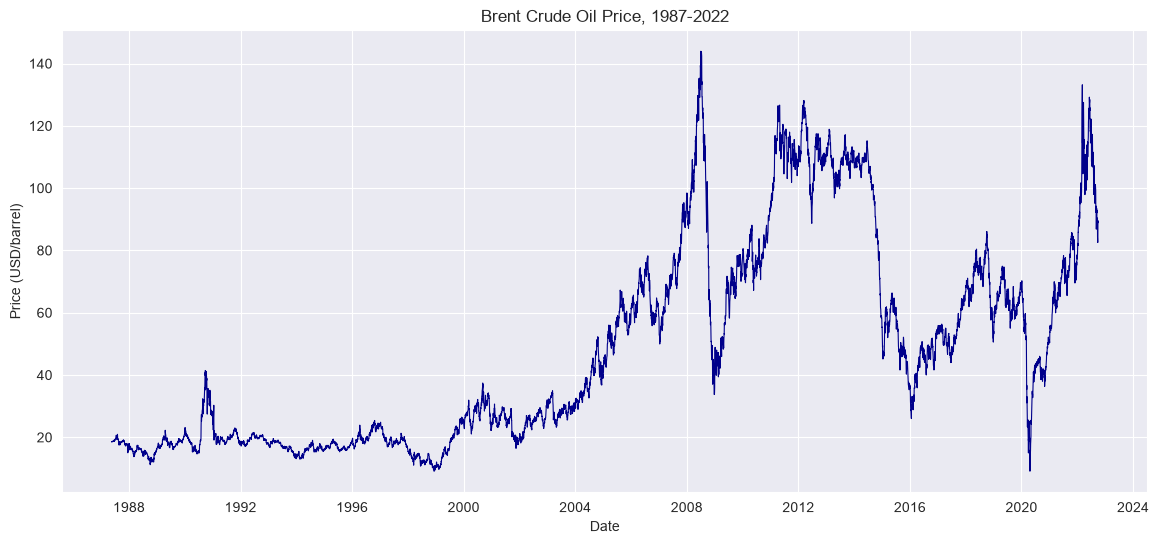

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["Price"], linewidth=0.8, color="darkblue")
ax.set_title("Brent Crude Oil Price, 1987-2022")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD/barrel)")
plt.show()

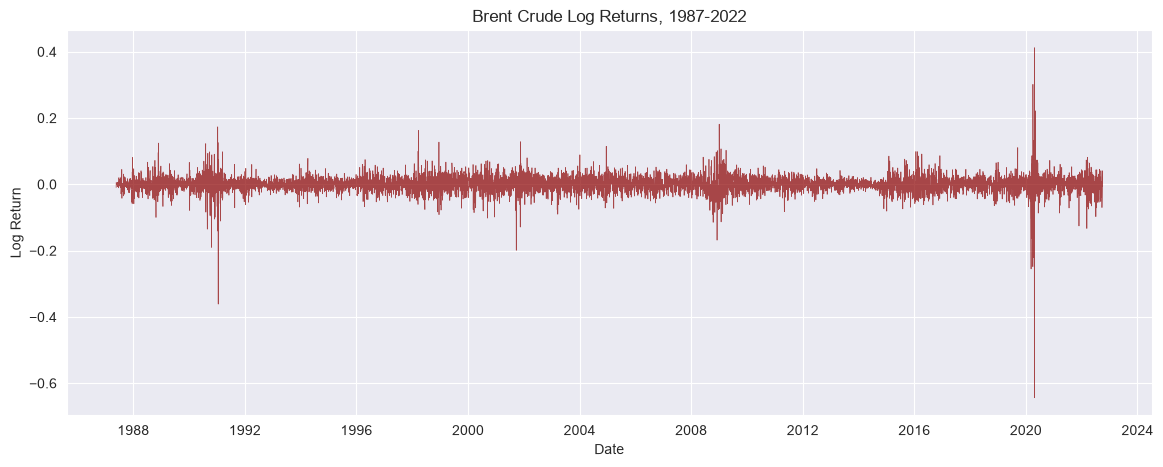

In [13]:
df["Log_Price"] = np.log(df["Price"])
df["Log_Return"] = df["Log_Price"].diff()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["Log_Return"], linewidth=0.5, color="darkred", alpha=0.7)
ax.set_title("Brent Crude Log Returns, 1987-2022")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
plt.show()

In [14]:
def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.6f}")
    is_stationary = result[1] < 0.05
    print(f"Stationary: {is_stationary}\n")
    return is_stationary

run_adf(df["Price"], "Raw Price")
run_adf(df["Log_Return"], "Log Return")

--- ADF Test: Raw Price ---
ADF Statistic: -2.0516
p-value: 0.264396
Stationary: False

--- ADF Test: Log Return ---
ADF Statistic: -16.3888
p-value: 0.000000
Stationary: True



np.True_

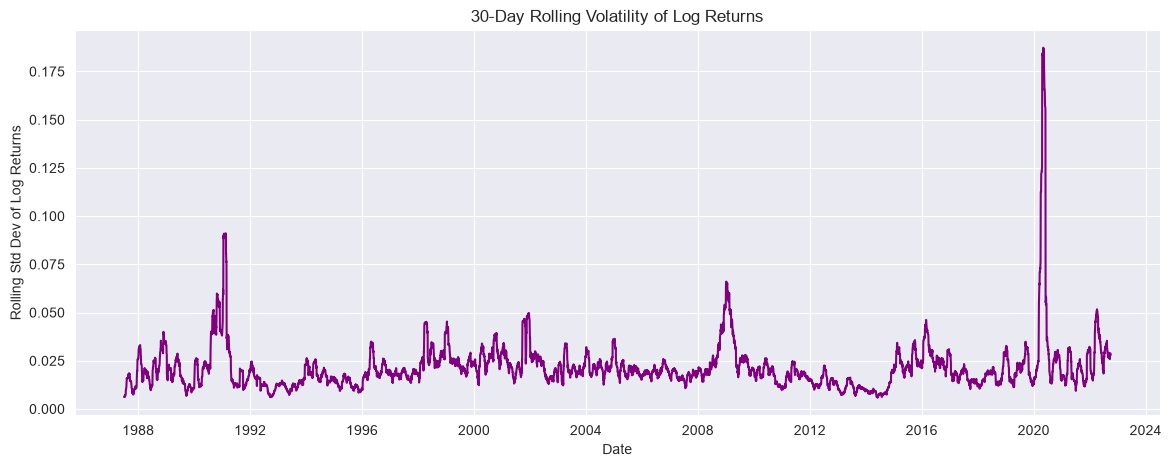

In [15]:
df["Rolling_Volatility_30d"] = df["Log_Return"].rolling(window=30).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["Rolling_Volatility_30d"], color="purple")
ax.set_title("30-Day Rolling Volatility of Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Std Dev of Log Returns")
plt.show()

## 5. Change Point Modeling: Rationale and Expected Outputs

**Why a change point model is appropriate here:** the EDA above demonstrates that 
Brent oil prices do not follow a single consistent statistical process across the 
full 1987-2022 window. The rolling volatility chart (Figure 3) shows distinct 
regimes of calm and turbulence rather than constant variance, and the ADF tests 
confirm the raw price series is non-stationary (p=0.289) while log returns are 
stationary (p<0.0001). A single global model (e.g., one mean and one variance 
fit to all 35 years at once) would badly misrepresent the data — it would average 
across fundamentally different market regimes (e.g., the calm mid-1990s and the 
turbulent 2020 COVID shock) rather than recognizing them as distinct periods. 
A change point model directly addresses this by allowing the model's parameters 
to shift at one or more specific points in time, rather than assuming one fixed 
process throughout.

**Purpose of the model:** to identify the specific point(s) in time at which the 
underlying statistical properties of the log return series shift, and to quantify 
how much they shift by — turning a visually apparent regime change (like those 
visible in Figures 1-3) into a precise, probabilistic statement.

**Model structure (to be implemented in `notebooks/2.0-change-point-model.ipynb`):**
- A discrete uniform prior over the switch point `tau`, treating every day as 
  equally likely to be the change point a priori
- Two distinct mean parameters (`mu_1`, `mu_2`) representing the average daily 
  log return before and after the switch point
- A shared standard deviation (`sigma`) — a simplifying assumption for the core 
  model; an extension allowing separate `sigma_1`/`sigma_2` per regime is a 
  natural next step given the volatility clustering observed in Figure 3
- A `pm.math.switch()` function selecting the correct mean for each time index 
  based on its position relative to `tau`
- A Normal likelihood connecting this switching mean to the observed log returns

**Expected outputs:**
- A posterior distribution over `tau`, giving a probable date (or narrow date 
  range) for the change point, with the *width* of that distribution itself 
  indicating how confident the model is about *when* the shift occurred
- Posterior distributions for `mu_1` and `mu_2`, enabling probabilistic statements 
  such as "with 95% probability, the average daily log return shifted from X to Y"
- A comparison between the detected change point date and the compiled key events 
  dataset (Section 1) to formulate hypotheses about likely causes

**Expected limitations:**
- A single change point model can only detect one structural break per run. 
  Given that Figures 1-3 show clear evidence of *multiple* distinct regimes 
  across 35 years (at minimum: 1990-91, 2008-09, 2014-16, and 2020), a single 
  run will only identify the *most statistically dominant* shift — likely 2020, 
  given it shows the most extreme volatility spike in the entire series. 
  Detecting the other regime changes will require either re-running the model 
  on sub-segments of the data, or extending to a multiple change point framework.
- As discussed in the assumptions and limitations documentation, a detected 
  change point represents statistical association in timing with a candidate 
  event, not proof of causal mechanism.